# Time series forecasting with TTM-R3

This notebook demonstrates how to use TTM-R3 in a time series forecasting task using the forecasting pipeline.  

## Preparing the experiments

To get started, please follow the installation instructions from [here](https://github.com/ibm-granite/granite-tsfm/?tab=readme-ov-file#initial-setup).

Import the necessary dependencies

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import torch

from tsfm_public import TimeSeriesForecastingPipeline
from tsfm_public.toolkit.get_model import get_model
from tsfm_public.toolkit.time_series_preprocessor import create_timestamps, prepare_data_splits

Prepare the configuration of the 

In [2]:
# Model configurations
model_path = "ibm-research/ttm-r3"

# Auxiliary configurations
seed = 0
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.mps.is_available() else "cpu")
print(f"Device: {device}")

dataset_path = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"
timestamp_column = "date"
id_columns = []  # mention the ids that uniquely identify a time-series.
target_columns = ["HUFL"]  # , "HULL", "MUFL", "MULL", "LUFL", "LULL", "OT"]

# prepare data splits according to the original example, but with revised context length
context_length = 2048
prediction_length = 96
split_config = {
    "train": [0, 8640],
    "valid": [8640, 11520],
    "test": [
        11520,
        14400,
    ],
}

data = pd.read_csv(
    dataset_path,
    parse_dates=[timestamp_column],
)
train_df, valid_df, test_df = prepare_data_splits(data, context_length=context_length, split_config=split_config)

batch_size = 16

Device: cuda


## Simple forecast with TimeSeriesForecastingPipeline

Load the model using the standard HuggingFace interface.

In [3]:
model = get_model(model_path, context_length=context_length, prediction_length=prediction_length, freq="H", use_lite=False)

INFO:p-2015258:t-22593302000320:get_model.py:get_model:Loading model from: ibm-research/ttm-r3
INFO:p-2015258:t-22593302000320:get_model.py:get_model:Loading model from: ibm-granite/granite-timeseries-ttm-r2
INFO:p-2015258:t-22593302000320:get_model.py:get_model:Model loaded successfully from ibm-research/ttm-r3, revision = 2048-96-r3.
INFO:p-2015258:t-22593302000320:get_model.py:get_model:[TTM] context_length = 2048, prediction_length = 96


In [4]:
all_data = test_df.iloc[: context_length + prediction_length + 10]  # take a smaller portion of the data

### Create a forecast using the forecasting pipeline

Here we pass information about the dataset columns, including:  
`timestamp_column`: column containing the timestamp  
`target_column`: target we want to forecast  

We also provide some options for how the data should be fed to the model:  
`max_context_length`: maximum size of the data to feed to the model, here we use the maximum consumable by the model (8192) -- this means context vectors up to this size will be passed.  
`context_length`: effectively the minimum amount of context provided to the model.  
`prediction_length`: length of predictions to generate.  
`imput_methd`: imptuation done during torch dataset creation. Here we choose None since PatchTST-FM can automatically impute the data.  
`quantile_levels`: quantiles chosen from among those used during pretraining (0.01 to 0.99 in increments of 0.01). For simplicity we choose two quantiles 0.1 and 0.9 and the median.  


In [5]:
pipe = TimeSeriesForecastingPipeline(
    model=model,
    id_columns=[],
    timestamp_column=timestamp_column,
    target_columns=target_columns,
    max_context_length=model.config.context_length,
    context_length=context_length,
    prediction_length=prediction_length,
    batch_size=batch_size,
    impute_method=None,
    device=device,
    quantile_levels=[0.1, 0.5, 0.9],
)

forecast_pipe = pipe(all_data)

Device set to use cuda
INFO:p-2015258:t-22593302000320:time_series_forecasting_pipeline.py:preprocess:Preprocessing with: {'prediction_length': 96, 'context_length': 2048, 'frequency_token': None, 'id_columns': [], 'timestamp_column': 'date', 'target_columns': ['HUFL'], 'impute_method': None, 'max_context_length': 2048}


target: torch.Size([16, 1, 96, 1]) torch.Size([16, 9, 96, 1])
target: torch.Size([16, 1, 96, 1]) torch.Size([16, 9, 96, 1])
target: torch.Size([16, 1, 96, 1]) torch.Size([16, 9, 96, 1])
target: torch.Size([16, 1, 96, 1]) torch.Size([16, 9, 96, 1])
target: torch.Size([16, 1, 96, 1]) torch.Size([16, 9, 96, 1])
target: torch.Size([16, 1, 96, 1]) torch.Size([16, 9, 96, 1])
target: torch.Size([11, 1, 96, 1]) torch.Size([11, 9, 96, 1])


In [6]:
forecast_pipe.head()

,date,HUFL_prediction,HUFL,HUFL_prediction_q0.1,HUFL_prediction_q0.2,HUFL_prediction_q0.3,HUFL_prediction_q0.4,HUFL_prediction_q0.5,HUFL_prediction_q0.6,HUFL_prediction_q0.7,HUFL_prediction_q0.8,HUFL_prediction_q0.9
0,2017-10-23 23:00:00,"[9.961517333984375, 9.8760404586792, 9.6713752...","[9.979999542236328, 8.305999755859375, 8.77400...","[5.600347518920898, 5.504276752471924, 5.27566...","[8.301400184631348, 8.204540252685547, 7.97458...","[9.014836311340332, 8.914546012878418, 8.67748...","[9.736777305603027, 9.652365684509277, 9.44993...","[9.961517333984375, 9.8760404586792, 9.6713752...","[10.521211624145508, 10.442288398742676, 10.25...","[10.557888984680176, 10.478771209716797, 10.28...","[11.282163619995117, 11.219076156616211, 11.06...","[11.58703327178955, 11.52338981628418, 11.3662..."
1,2017-10-24 00:00:00,"[10.131385803222656, 9.817451477050781, 10.252...","[8.305999755859375, 8.77400016784668, 8.104999...","[5.914391040802002, 5.562509059906006, 6.04891...","[8.623429298400879, 8.26872444152832, 8.759280...","[9.2162504196167, 8.852007865905762, 9.3558578...","[9.932079315185547, 9.621257781982422, 10.0523...","[10.131385803222656, 9.817451477050781, 10.252...","[10.666388511657715, 10.373536109924316, 10.78...","[10.700822830200195, 10.407384872436523, 10.81...","[11.423446655273438, 11.18421459197998, 11.517...","[11.720231056213379, 11.479164123535156, 11.81..."
2,2017-10-24 01:00:00,"[8.595565795898438, 8.999212265014648, 8.83788...","[8.77400016784668, 8.104999542236328, 8.439000...","[3.9600982666015625, 4.430828094482422, 4.2456...","[6.778121471405029, 7.248056888580322, 7.06287...","[7.413638114929199, 7.897772312164307, 7.70738...","[8.351960182189941, 8.750312805175781, 8.59095...","[8.595565795898438, 8.999212265014648, 8.83788...","[9.282663345336914, 9.652793884277344, 9.50382...","[9.334192276000977, 9.705999374389648, 9.55643...","[10.374610900878906, 10.650299072265625, 10.53...","[10.72022819519043, 10.997968673706055, 10.882..."
3,2017-10-24 02:00:00,"[9.391725540161133, 9.087671279907227, 9.77447...","[8.104999542236328, 8.439000129699707, 8.43900...","[4.921895980834961, 4.56649923324585, 5.366681...","[7.7368621826171875, 7.3805999755859375, 8.184...","[8.316343307495117, 7.951137065887451, 8.77687...","[9.203400611877441, 8.902257919311523, 9.58207...","[9.391725540161133, 9.087671279907227, 9.77447...","[9.978626251220703, 9.696786880493164, 10.3316...","[10.006025314331055, 9.723630905151367, 10.359...","[10.847158432006836, 10.62655258178711, 11.122...","[11.06241226196289, 10.840753555297852, 11.339..."
4,2017-10-24 03:00:00,"[7.856627941131592, 8.539834976196289, 9.55872...","[8.439000129699707, 8.439000129699707, 9.64500...","[2.9547135829925537, 3.801724672317505, 4.9964...","[5.900548458099365, 6.739285469055176, 7.93707...","[6.437657833099365, 7.302309989929199, 8.53201...","[7.656355857849121, 8.331452369689941, 9.33869...","[7.856627941131592, 8.539834976196289, 9.55872...","[8.582673072814941, 9.205728530883789, 10.1438...","[8.616064071655273, 9.241565704345703, 10.1823...","[9.862090110778809, 10.28989028930664, 11.0016...","[10.090582847595215, 10.520689010620117, 11.23..."


In [7]:
len(forecast_pipe[f"{target_columns[0]}_prediction"].iloc[0])

96

## Plot the results

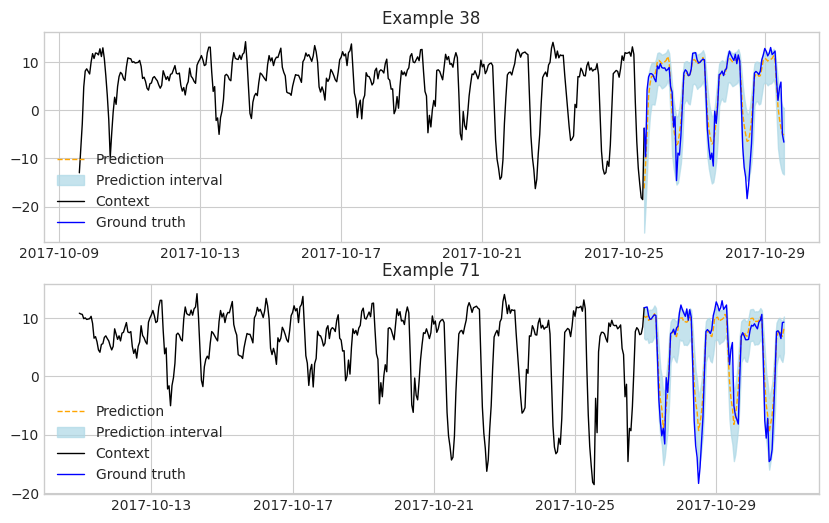

In [8]:
# plotting
plt.style.use("seaborn-v0_8-whitegrid")

indices = [38, 71]

plot_context = 4 * prediction_length
num_plots = len(indices)
freq = "h"
channel = target_columns[0]
channel_pred = f"{channel}_prediction_q0.5"
channel_lower = f"{channel}_prediction_q0.1"
channel_upper = f"{channel}_prediction_q0.9"


gt_df = test_df.copy()
gt_df = gt_df.set_index(timestamp_column)
forecast = forecast_pipe

fig, axs = plt.subplots(num_plots, 1, figsize=(10, 3 * num_plots))

for i, idx in enumerate(indices):
    this_forecast = forecast.iloc[idx]  # forecast[forecast["id"] == idx].iloc[0]
    ts_y_hat = create_timestamps(this_forecast[timestamp_column], freq=freq, periods=prediction_length)

    y_hat = this_forecast[channel_pred]
    y_hat_lower = this_forecast[channel_lower]
    y_hat_upper = this_forecast[channel_upper]

    loc = gt_df.index.get_loc(this_forecast[timestamp_column])
    ts_index = gt_df.index[loc - plot_context + 1 : loc + 2]  #  + prediction_length]
    y = gt_df.loc[ts_index][channel]
    ts_y = y.index
    y = y.values

    ts_index = gt_df.index[loc + 1 : loc + 1 + prediction_length]
    y2 = gt_df.loc[ts_index][channel]
    ts_y2 = y2.index
    y2 = y2.values

    axs[i].plot(ts_y_hat, y_hat, label="Prediction", linestyle="--", color="orange", linewidth=1)
    axs[i].fill_between(
        ts_y_hat, y_hat_lower, y_hat_upper, label="Prediction interval", alpha=0.7, color="lightblue", linewidth=1
    )

    axs[i].plot(ts_y, y, label="Context", linestyle="-", color="black", linewidth=1)
    axs[i].plot(ts_y2, y2, label="Ground truth", linestyle="-", color="blue", linewidth=1)
    axs[i].set_title(f"Example {idx}")
    axs[i].legend(loc="lower left")

## Links
* Library: [Granite TSFM on Github](https://github.com/ibm-granite/granite-tsfm)
* Model: [TTM-R3 on HuggingFace](https://huggingface.co/ibm-research/ttm-r3)
* Dataset: [Electrical Transformer Dataset](https://github.com/zhouhaoyi/ETDataset)